In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.feature_sets import BASE_TABULAR_FEATURES, GCMT_FEATURES
from src.models.input_layer import load_modeling_splits

DATASET_NAME = "earthquake_aftershock_v2_gcmt"
HORIZONS = ["24h", "72h"]
OUTPUT_DIR = PROJECT_ROOT / "reports" / "metrics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available. Notebook will run on CPU.")

PyTorch version: 2.5.1+cu121
Using device: cuda
GPU: NVIDIA GeForce RTX 3070


In [2]:
splits = load_modeling_splits(dataset_name=DATASET_NAME)
train_df = splits["train"].copy()
val_df = splits["val"].copy()
test_df = splits["test"].copy()

print(f"Train: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

TARGET_CAPS = {
    "24h": 300.0,
    "72h": 500.0,
}

Train: 23,031 rows
Val:   1,744 rows
Test:  3,513 rows


In [3]:
def zinb_loss(y: torch.Tensor, logit_pi: torch.Tensor, mu: torch.Tensor, theta: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Compute Zero-Inflated Negative Binomial negative log-likelihood.
    
    Args:
        y: observed counts, shape (batch_size,)
        logit_pi: logit of zero-inflation probability, shape (batch_size,)
        mu: mean of NB distribution, shape (batch_size,)
        theta: dispersion parameter (shape), shape (batch_size,)
        eps: small constant for numerical stability
    
    Returns:
        Scalar loss (average negative log-likelihood over batch)
    """
    # Ensure mu and theta are positive
    mu = F.softplus(mu) + eps
    theta = F.softplus(theta) + eps
    
    # Probability of zero-inflation
    pi = torch.sigmoid(logit_pi)
    pi = torch.clamp(pi, eps, 1.0 - eps)
    
    # NB probability mass function: P(y; mu, theta)
    # Using parameterization: NB(k; mu, r) where r = theta (shape) and mu is mean
    # P(k) = Gamma(k + r) / (k! * Gamma(r)) * (r/(r+mu))^r * (mu/(r+mu))^k
    
    # Log-likelihood for zero counts
    log_nb_zero = theta * (torch.log(theta) - torch.log(theta + mu)) - torch.lgamma(theta + eps)
    
    # Log-likelihood for non-zero counts
    log_nb_y = (
        torch.lgamma(y + theta + eps)
        - torch.lgamma(y + 1.0 + eps)
        - torch.lgamma(theta + eps)
        + theta * (torch.log(theta) - torch.log(theta + mu))
        + y * (torch.log(mu) - torch.log(theta + mu))
    )
    
    # Combine: P(y=0) = pi + (1-pi)*NB(0), P(y>0) = (1-pi)*NB(y)
    zero_mask = (y == 0).float()
    nonzero_mask = 1.0 - zero_mask
    
    # Log likelihood
    log_likelihood = (
        zero_mask * torch.logsumexp(
            torch.stack([torch.log(pi + eps), torch.log(1.0 - pi + eps) + log_nb_zero], dim=1),
            dim=1
        )
        + nonzero_mask * (torch.log(1.0 - pi + eps) + log_nb_y)
    )
    
    return -log_likelihood.mean()


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, model_name: str, horizon: str, split: str) -> dict:
    """Compute MAE and RMSE for count predictions."""
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return {
        "model_name": model_name,
        "horizon": horizon,
        "split": split,
        "MAE": round(float(mae), 4),
        "RMSE": round(float(rmse), 4),
    }

In [4]:
class ZINBNet(nn.Module):
    """
    Zero-Inflated Negative Binomial neural network.
    
    Outputs:
        - logit_pi: logit of zero-inflation probability
        - mu: mean of negative binomial (will be softplus'd in loss)
        - theta: dispersion parameter (will be softplus'd in loss)
    """
    def __init__(self, n_features: int, hidden_dim: int = 256, dropout: float = 0.25):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.SiLU(),
            nn.Dropout(dropout),
        )
        
        # Three heads for ZINB parameters
        self.pi_head = nn.Linear(hidden_dim // 2, 1)      # logit scale (sigmoid in loss)
        self.mu_head = nn.Linear(hidden_dim // 2, 1)      # mean (softplus in loss)
        self.theta_head = nn.Linear(hidden_dim // 2, 1)   # dispersion (softplus in loss)
    
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        h = self.backbone(x)
        logit_pi = self.pi_head(h).squeeze(-1)
        mu = self.mu_head(h).squeeze(-1)
        theta = self.theta_head(h).squeeze(-1)
        return logit_pi, mu, theta

In [5]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = BASE_TABULAR_FEATURES + GCMT_FEATURES

DEFAULT_CFG = {
    "batch_size": 256,
    "epochs": 100,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "patience": 20,
    "hidden_dim": 256,
    "dropout": 0.25,
    "clip_grad": 1.0,
}

HORIZON_CONFIGS = {
    "24h": {
        "batch_size": 256,
        "epochs": 100,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "patience": 20,
        "hidden_dim": 256,
        "dropout": 0.25,
        "clip_grad": 1.0,
    },
    "72h": {
        "batch_size": 192,
        "epochs": 120,
        "lr": 8e-4,
        "weight_decay": 1.5e-4,
        "patience": 25,
        "hidden_dim": 256,
        "dropout": 0.25,
        "clip_grad": 1.0,
    },
}

all_metrics = []
training_history = {}

In [6]:
def prepare_arrays(df: pd.DataFrame, feature_cols: list[str], target_col: str) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    """Prepare and clean data."""
    keep_cols = feature_cols + [target_col, "trigger_event_id"]
    out = df[keep_cols].copy()
    out = out.dropna(subset=[target_col])
    X = out[feature_cols]
    y = out[target_col].astype(float)
    return out, X, y

for horizon in HORIZONS:
    cfg = {**DEFAULT_CFG, **HORIZON_CONFIGS.get(horizon, {})}
    target_col = f"n_aftershocks_{horizon}"
    print(f"\n{'='*70}")
    print(f"Horizon: {horizon} | Target: {target_col}")
    print(f"Config: batch_size={cfg['batch_size']}, epochs={cfg['epochs']}, lr={cfg['lr']}, hidden={cfg['hidden_dim']}")
    print(f"{'='*70}")
    
    train_keep, X_train_df, y_train_s = prepare_arrays(train_df, FEATURE_COLS, target_col)
    val_keep, X_val_df, y_val_s = prepare_arrays(val_df, FEATURE_COLS, target_col)
    test_keep, X_test_df, y_test_s = prepare_arrays(test_df, FEATURE_COLS, target_col)
    
    # Apply evaluation-only cap (keep training targets uncapped)
    target_cap = TARGET_CAPS.get(horizon)
    if target_cap is not None:
        y_val_s = y_val_s.clip(upper=target_cap)
        print(f"Applied val-only cap for {horizon}: {target_cap:.0f}")
    
    # Preprocessing
    X_train_df = X_train_df.copy()
    X_val_df = X_val_df.copy()
    X_test_df = X_test_df.copy()
    
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    
    X_train = scaler.fit_transform(imputer.fit_transform(X_train_df[FEATURE_COLS])).astype(np.float32)
    X_val = scaler.transform(imputer.transform(X_val_df[FEATURE_COLS])).astype(np.float32)
    X_test = scaler.transform(imputer.transform(X_test_df[FEATURE_COLS])).astype(np.float32)
    
    y_train = y_train_s.to_numpy(dtype=np.float32)
    y_val = y_val_s.to_numpy(dtype=np.float32)
    y_test = y_test_s.to_numpy(dtype=np.float32)
    
    # Create PyTorch datasets and dataloaders
    train_ds = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train),
    )
    val_ds = TensorDataset(
        torch.from_numpy(X_val),
        torch.from_numpy(y_val),
    )
    
    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False)
    
    # Model, optimizer, scheduler
    model = ZINBNet(
        n_features=X_train.shape[1],
        hidden_dim=cfg["hidden_dim"],
        dropout=cfg["dropout"],
    ).to(device)
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
    )
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4,
        threshold=1e-4,
        min_lr=1e-6,
    )
    
    best_state = None
    best_val_loss = float("inf")
    patience_ctr = 0
    history_rows = []
    
    def predict_zinb_mean(X_np: np.ndarray) -> np.ndarray:
        """Predict expected count E[y|x] from ZINB model."""
        xb = torch.from_numpy(X_np).to(device)
        with torch.no_grad():
            logit_pi, mu, theta = model(xb)
            pi = torch.sigmoid(logit_pi)
            mu_np = F.softplus(mu).detach().cpu().numpy()
            # E[y] = (1 - pi) * mu
            expected_counts = (1.0 - pi.detach().cpu().numpy()) * mu_np
        return expected_counts.astype(np.float64)
    
    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        train_loss_sum = 0.0
        
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            
            optimizer.zero_grad()
            logit_pi, mu, theta = model(xb)
            
            loss = zinb_loss(yb, logit_pi, mu, theta)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg["clip_grad"])
            optimizer.step()
            
            train_loss_sum += loss.item() * xb.size(0)
        
        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                
                logit_pi, mu, theta = model(xb)
                loss = zinb_loss(yb, logit_pi, mu, theta)
                val_loss_sum += loss.item() * xb.size(0)
        
        train_loss = train_loss_sum / len(train_ds)
        val_loss = val_loss_sum / len(val_ds)
        scheduler.step(val_loss)
        
        history_rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "lr": optimizer.param_groups[0]["lr"],
        })
        
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= cfg["patience"]:
                print(f"Early stopping at epoch {epoch}.")
                break
    
    training_history[horizon] = pd.DataFrame(history_rows)
    
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    
    preds_train = predict_zinb_mean(X_train)
    preds_val = predict_zinb_mean(X_val)
    preds_test = predict_zinb_mean(X_test)
    
    model_name = "zinb_gpu"
    
    all_metrics.append(compute_metrics(y_train, preds_train, model_name, horizon, "train"))
    all_metrics.append(compute_metrics(y_val, preds_val, model_name, horizon, "val"))
    all_metrics.append(compute_metrics(y_test, preds_test, model_name, horizon, "test"))
    
    print("\nMetrics:")
    for row in all_metrics[-3:]:
        print(f"  [{row['split']}] MAE={row['MAE']:.4f} RMSE={row['RMSE']:.4f}")


Horizon: 24h | Target: n_aftershocks_24h
Config: batch_size=256, epochs=100, lr=0.001, hidden=256
Applied val-only cap for 24h: 300
Epoch 001 | train_loss=2.7358 | val_loss=3.2917 | lr=1.00e-03
Epoch 010 | train_loss=1.9142 | val_loss=2.9710 | lr=1.00e-03
Epoch 020 | train_loss=1.8762 | val_loss=2.9241 | lr=2.50e-04
Early stopping at epoch 26.

Metrics:
  [train] MAE=6.6595 RMSE=23.4403
  [val] MAE=13.0185 RMSE=40.3413
  [test] MAE=9.3136 RMSE=26.2663

Horizon: 72h | Target: n_aftershocks_72h
Config: batch_size=192, epochs=120, lr=0.0008, hidden=256
Applied val-only cap for 72h: 500
Epoch 001 | train_loss=3.4844 | val_loss=4.0683 | lr=8.00e-04
Epoch 010 | train_loss=2.2736 | val_loss=3.5079 | lr=8.00e-04
Epoch 020 | train_loss=2.2299 | val_loss=3.6349 | lr=2.00e-04
Epoch 030 | train_loss=2.2237 | val_loss=3.6289 | lr=5.00e-05
Early stopping at epoch 31.

Metrics:
  [train] MAE=10.7645 RMSE=38.6339
  [val] MAE=20.2018 RMSE=60.2472
  [test] MAE=14.2374 RMSE=40.1164


In [7]:
metrics_zinb_df = pd.DataFrame(all_metrics)

print("=== ZINB Test Results ===")
print(
    metrics_zinb_df[metrics_zinb_df["split"] == "test"]
    .sort_values(["horizon", "MAE"])
    .to_string(index=False)
)

metrics_path = OUTPUT_DIR / "zinb_gpu_metrics.csv"
metrics_zinb_df.to_csv(metrics_path, index=False)

print(f"\nSaved metrics to: {metrics_path}")

=== ZINB Test Results ===
model_name horizon split     MAE    RMSE
  zinb_gpu     24h  test  9.3136 26.2663
  zinb_gpu     72h  test 14.2374 40.1164

Saved metrics to: C:\Users\natas\OneDrive\Desktop\CDS_Group10\reports\metrics\zinb_gpu_metrics.csv


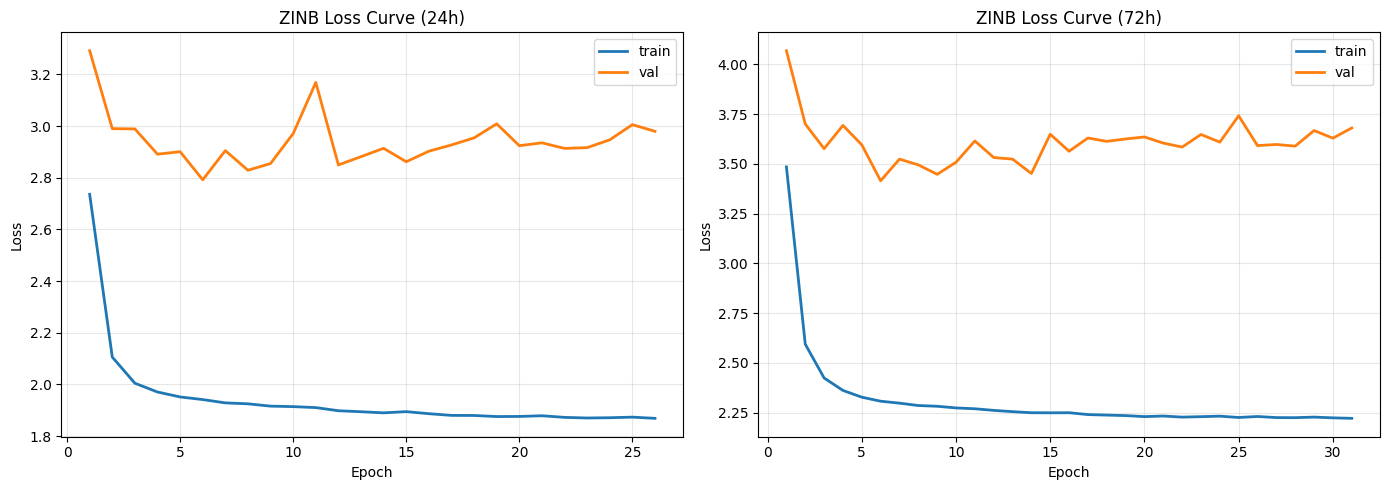

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, horizon in zip(axes, HORIZONS):
    hist_df = training_history[horizon]
    ax.plot(hist_df["epoch"], hist_df["train_loss"], label="train", linewidth=2)
    ax.plot(hist_df["epoch"], hist_df["val_loss"], label="val", linewidth=2)
    ax.set_title(f"ZINB Loss Curve ({horizon})", fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()